
Duplicate of 2025-10-29 plot nodes with new data. 

In [1]:
from nilearn import datasets
import nilearn
from nilearn.plotting import plot_roi, show
import nibabel as nib
import pandas as pd
import matplotlib.pyplot as plt
from nilearn import input_data

import numpy as np
from nilearn import plotting

/tmp/ipykernel_566110/2626990669.py:7: DeprecationWarning: The import path 'nilearn.input_data' is deprecated in version 0.9. Importing from 'nilearn.input_data' will be possible at least until release 0.13.0. Please import from 'nilearn.maskers' instead.
  from nilearn import input_data


In [2]:
schaefer = datasets.fetch_atlas_schaefer_2018(n_rois=100) 

[fetch_atlas_schaefer_2018] Dataset found in /global/homes/m/mphagen/nilearn_data/schaefer_2018


In [3]:
msmall_df = pd.read_csv('msmall_r2_2025-11-04.csv')
#get average of problematic nodes across folds and subjects 
msmall_nodes = msmall_df.groupby('node').mean(numeric_only =True).mean(axis=1).sort_values() 

In [62]:
msmall_df.columns.sort_values() 

Index(['fold', 'node', 'sub-102109', 'sub-102109.1', 'sub-103010',
       'sub-103010.1', 'sub-105014', 'sub-105014.1', 'sub-111413',
       'sub-111413.1',
       ...
       'sub-899885', 'sub-899885.1', 'sub-930449', 'sub-930449.1',
       'sub-937160', 'sub-937160.1', 'sub-947668', 'sub-947668.1',
       'sub-979984', 'sub-979984.1'],
      dtype='object', length=102)

In [4]:
xcpd_df = pd.read_csv('xcpd_r2_2025-10-24_r2.csv')
#get average of problematic nodes across folds and subjects 
xcpd_nodes = xcpd_df.groupby('node').mean(numeric_only =True).mean(axis=1).sort_values() 

In [5]:
atlas_file = schaefer['maps']

atlas = nib.load(atlas_file) 

In [6]:
atlas_labels = schaefer['labels']

In [7]:
from scipy.stats import zscore


In [74]:
atlas = nib.load(atlas_file) 
msmall_atlas = atlas.get_fdata()

for ii in msmall_nodes.index  : 
        #xcpd_atlas is 1 indexed, xcpd_node_df is 0 indexed
        msmall_atlas[np.isin(nilearn.image.get_data(atlas),
                           (int(ii.replace('node_', '')) + 1)) ] = msmall_nodes[ii]


In [18]:
atlas = nib.load(atlas_file) 
outlier_msmall_atlas = atlas.get_fdata()

for ii in msmall_nodes[zscore(msmall_nodes) < -2].index  : 
        #xcpd_atlas is 1 indexed, xcpd_node_df is 0 indexed
        outlier_msmall_atlas[np.isin(nilearn.image.get_data(atlas),
                           (int(ii.replace('node_', '')) + 1)) ] = msmall_nodes[ii]

for ii in msmall_nodes[zscore(msmall_nodes) > -2].index: 
     outlier_msmall_atlas[np.isin(nilearn.image.get_data(atlas),
                           (int(ii.replace('node_', '')) + 1)) ] = 0 

In [28]:
#some of the MSMAll outliers are only outliers in one fold, but not if the folds are averaged together. 
atlas = nib.load(atlas_file) 
single_fold_msmall = atlas.get_fdata()

#from 10_8_2025_msmall.ipynb: 
msmall_dict = {'node_10': 1,
         'node_18': 1,
         'node_36': 1,
         'node_76': 1,
         'node_86': 1}

for ii in msmall_nodes.index : 
    if ii in list(msmall_dict.keys()): 
        #xcpd_atlas is 1 indexed, xcpd_node_df is 0 indexed
        single_fold_msmall[np.isin(nilearn.image.get_data(atlas),
                           (int(ii.replace('node_', '')) + 1)) ] = msmall_nodes[ii]
    else: 
        single_fold_msmall[np.isin(nilearn.image.get_data(atlas),
                           (int(ii.replace('node_', '')) + 1)) ] = 0 


atlas = nib.load(atlas_file) 

mask_img = nilearn.image.new_img_like(atlas, single_fold_msmall)
plotting.plot_stat_map(
mask_img, vmax=1, vmin=-1, cmap='berlin', display_mode='mosaic', title='MSMALL R2')  
plt.savefig('msmall_acc_mosaic.pdf') 
plotting.show()

In [51]:
msmall_nodes[10:]

node
node_24    0.460962
node_32    0.503497
node_91    0.509705
node_10    0.523518
node_48    0.565070
             ...   
node_81    0.850905
node_57    0.860544
node_40    0.869785
node_56    0.870442
node_7     0.892349
Length: 90, dtype: float64

In [48]:
msmall_nodes[:10] 

node
node_30    0.244729
node_78    0.256201
node_31    0.334867
node_79    0.360132
node_0     0.383660
node_41    0.406880
node_50    0.408523
node_93    0.430537
node_36    0.435534
node_86    0.436992
dtype: float64

In [46]:
msmall_nodes[['node_10', 'node_18', 'node_36']]

node
node_10    0.523518
node_18    0.659447
node_36    0.435534
dtype: float64

In [50]:
xcpd_nodes[:10]

node
node_30   -0.082808
node_78   -0.053080
node_31    0.265253
node_93    0.288425
node_41    0.297401
node_50    0.316087
node_79    0.318821
node_0     0.351028
node_24    0.357929
node_36    0.447280
dtype: float64

In [13]:
atlas = nib.load(atlas_file) 
xcpd_atlas = atlas.get_fdata()

for ii in xcpd_nodes.index : 
        #xcpd_atlas is 1 indexed, xcpd_node_df is 0 indexed
        xcpd_atlas[np.isin(nilearn.image.get_data(atlas),
                           (int(ii.replace('node_', '')) + 1)) ] = xcpd_nodes[ii]
#xcpd_atlas[!np.isin(nilearn.image.get_data(atlas), node_list)] = xcpd_node_df['r2'].iloc[ii]

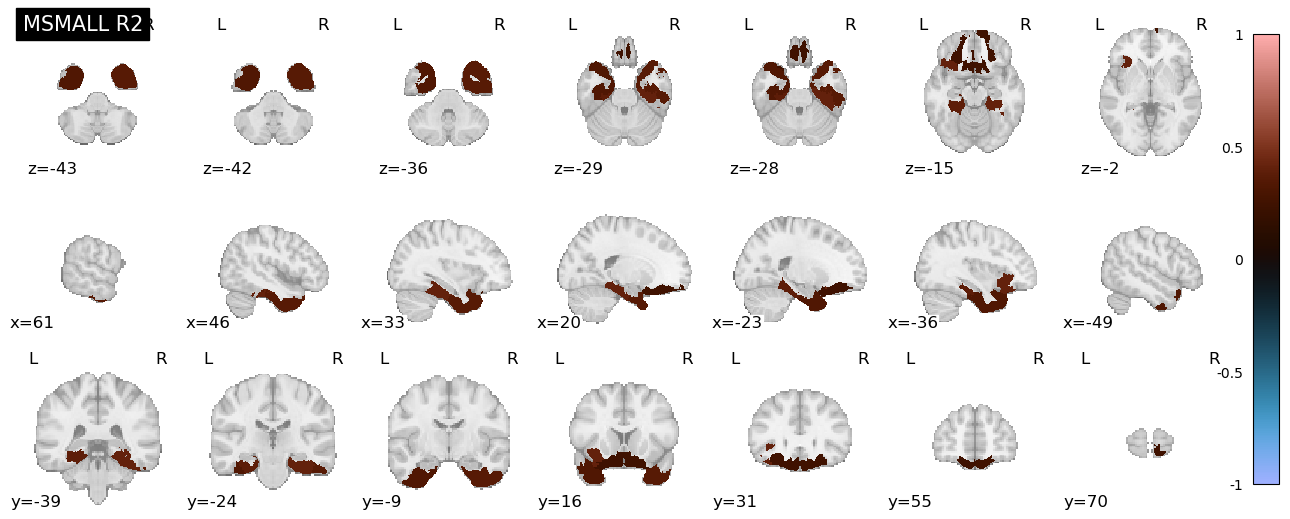

In [88]:
atlas = nib.load(atlas_file) 

mask_img = nilearn.image.new_img_like(atlas, outlier_msmall_atlas)
plotting.plot_stat_map(
mask_img, vmax=1, vmin=-1, cmap='berlin', display_mode='mosaic', title='MSMALL R2')  
plt.savefig('msmall_acc_mosaic_thresh.pdf') 
plotting.show()


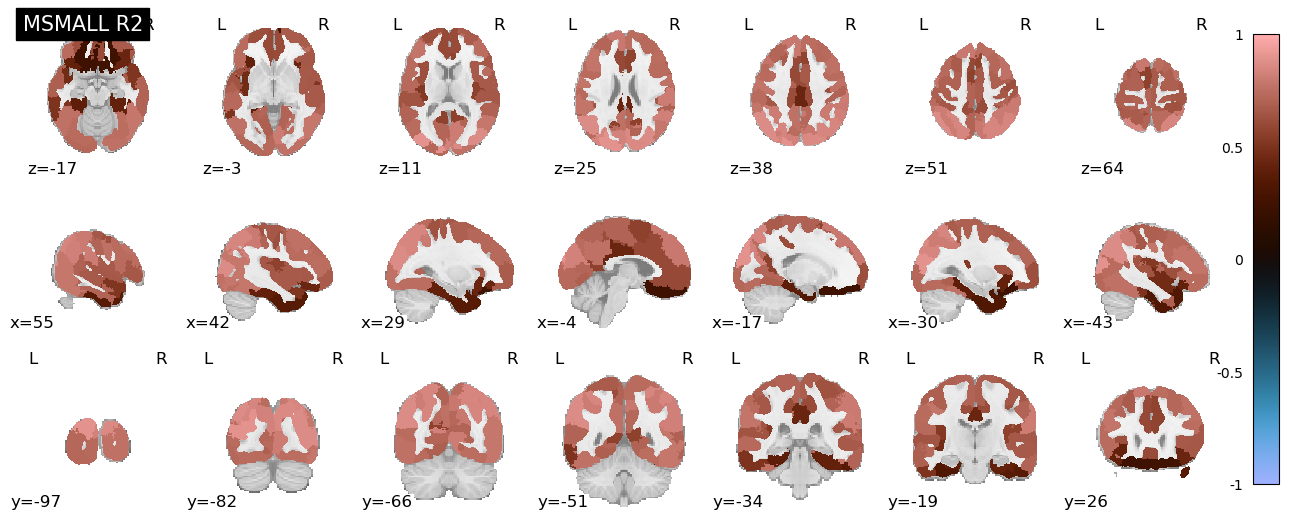

In [78]:
mask_img = nilearn.image.new_img_like(atlas, msmall_atlas)
plotting.plot_stat_map(
mask_img,vmax=1, vmin=-1, cmap='berlin', display_mode='mosaic', title='MSMALL R2')  
plt.savefig('msmall_acc_mosaic.pdf') 
plotting.show()


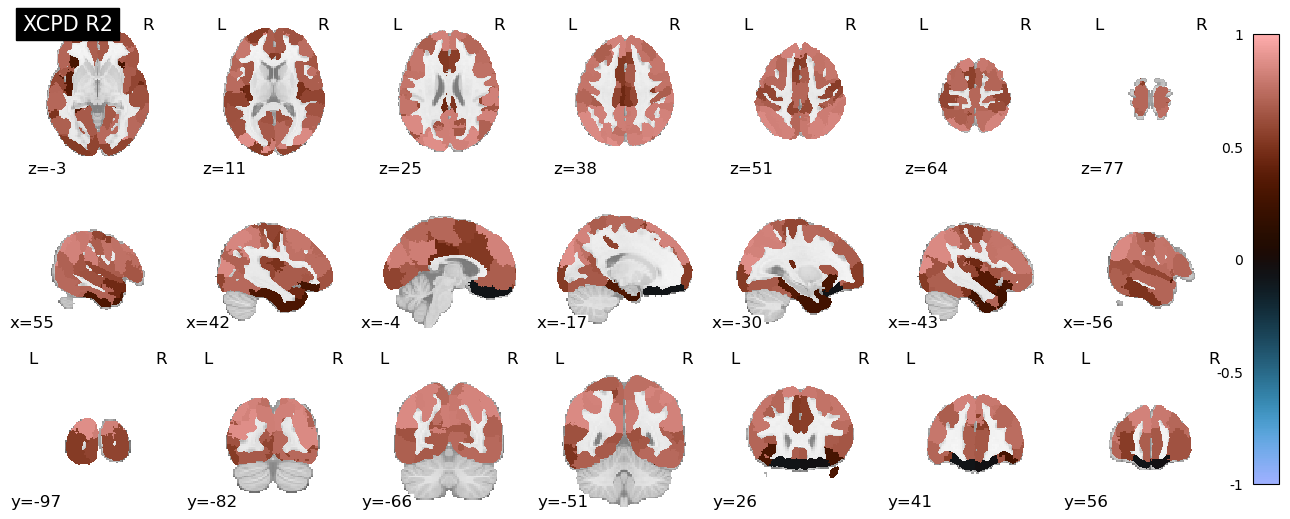

In [31]:
mask_img = nilearn.image.new_img_like(atlas, xcpd_atlas)
plotting.plot_stat_map(
mask_img,vmax=1, vmin=-1, cmap='berlin', display_mode='mosaic', title='XCPD R2')  
plt.savefig('xcpd_acc_mosaic.pdf') 
plotting.show()


In [32]:
xcpd_atlas.min()

np.float64(-0.0828081910610199)

In [33]:
xcpd_atlas.max() 

np.float64(0.8792413568496704)

In [34]:
msmall_atlas.min() 

np.float64(0.0)

In [35]:
msmall_atlas.max() 

np.float64(0.8923494977951049)

In [36]:
(xcpd_atlas - msmall_atlas).max() 

np.float64(0.0857814481258391)

In [37]:
(xcpd_atlas - msmall_atlas).min() 

np.float64(-0.32753728842735286)

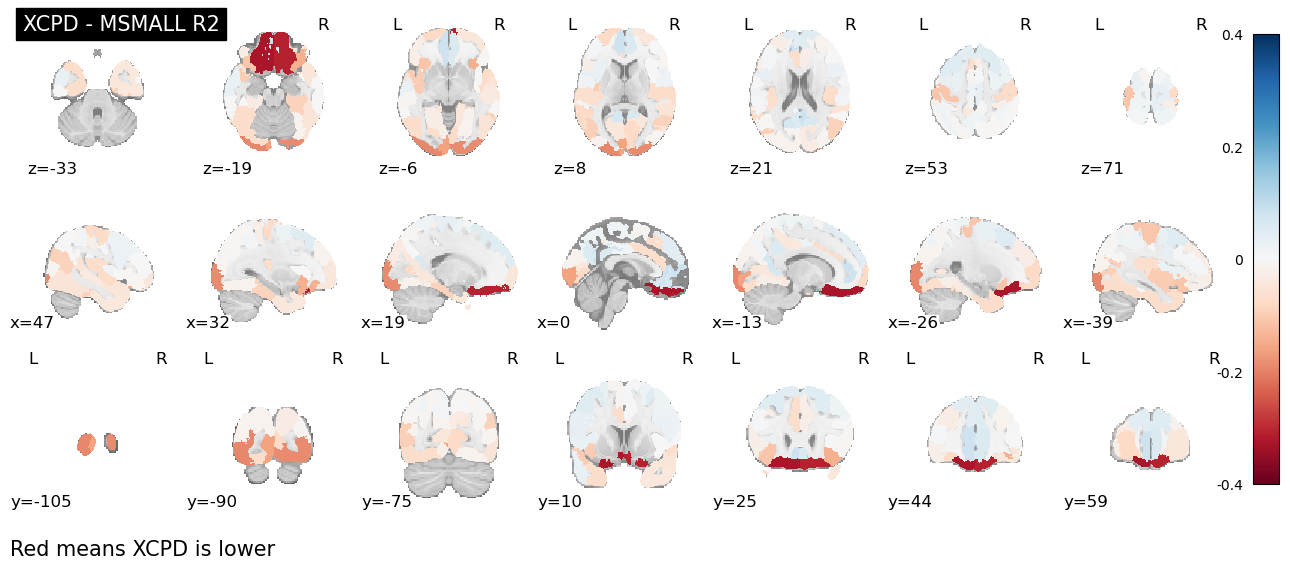

In [87]:
mask_img = nilearn.image.new_img_like(atlas, (xcpd_atlas - msmall_atlas))

display = plotting.plot_stat_map(
mask_img,vmax=.4, vmin=-.4, cmap='RdBu', title = 'XCPD - MSMALL R2' , display_mode='mosaic') 
display.frame_axes.text(0,-.1, 'Red means XCPD is lower', ha='left', va='bottom', fontsize=15)
plt.savefig('xcpd-msmall_acc_mosaic.pdf') 
plotting.show()